# Synthetic track (TODO.md Sec. 3)

A 2D, 3-class toy that replicates Fig. 4 of Roy et al., *Uncertainty-guided Source-free Domain Adaptation* (U-SFAN, `paper/U-SFAN.pdf`), using this project's own last-layer Laplace + BALD + IM-adaptation code (`bayesian.py`, `im_adapt.py`) on a problem small enough to fully inspect before trusting the same machinery on UCI HAR.

Three boxes, matching the TODO checklist:

1. **Fig. 4 replication** -- MAP (conventional) vs. uncertainty-guided IM, under two shift regimes. `mild` acts as a *negative control* (an already-correct target that adaptation must not break); `strong` is the real test. Both rows also show the class-probability surface faded by confidence.
2. **Semantic check** -- a point far from the source data should be *epistemic*-dominant; a point near a class boundary but well inside the source support should be *aleatoric*-dominant.
3. **Optional shift-magnitude sweep** -- drag one cluster progressively farther away and check that mean epistemic uncertainty tracks the (known) ground-truth shift magnitude.

*Note on quantities.* Box 1's adaptation down-weights each sample by `exp(-H)` where `H` is the **total** predictive entropy of the frozen Bayesian head (Eq. 6-7 of the paper). The epistemic/aleatoric decomposition shown in Boxes 2-3 is a **diagnostic** of *why* `H` is large in a given region; it is not itself the weight that enters the loss.

In [1]:
import copy

import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from bayesian import LastLayerLaplace
from im_adapt import adapt_target
import toy

np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110

SEED = 0  # global reproducibility knob for the Monte-Carlo predictive
N = toy.N_CLASSES

## Setup: source model + last-layer Laplace posterior

A small MLP feature extractor (`2 -> 32 -> 16`, ReLU) followed by a linear head is trained to a MAP solution on the 3-class source data (red / green / blue blobs). We then fit the exact last-layer Laplace posterior over the head only, exactly as in `TODO.md` Sec. 1b/5: `H = sum_n (Lambda_n kron phi_n phi_n^T) + tau_prior * I`.

One deliberate deviation from the naive `tau_prior = weight_decay * N_source` convention: at that value the fitted posterior is so tight that it reproduces the textbook ReLU-overconfidence pathology almost everywhere -- the *mean* logit gap grows just as fast as the *std* away from the data, so confidence never meaningfully drops with distance. Scaling `tau_prior` down by `TAU_SCALE` widens the last-layer posterior enough that the Kristiadi-et-al.-style correction (TODO.md Sec. 3b) actually becomes visible at finite distances. This is a toy-specific calibration choice, not a general recipe -- flagged here so it isn't mistaken for the real HAR pipeline's convention.

In [2]:
TAU_SCALE = 0.01  # see note above
HIDDEN_DIMS = [32, 16]

Xs, ys = toy.make_source(seed=0)
model = toy.build_model(hidden_dims=HIDDEN_DIMS, seed=0)
tau_prior = toy.train_map(model, Xs, ys, weight_decay=1e-2, lr=1e-2, epochs=500)
laplace = LastLayerLaplace.fit(model, torch.as_tensor(Xs), torch.as_tensor(ys),
                               tau_prior=tau_prior * TAU_SCALE)

with torch.no_grad():
    train_acc = (model(torch.as_tensor(Xs)).argmax(dim=1).numpy() == ys).mean()
eigvals = torch.linalg.eigvalsh(laplace.cov)
print(f"source MAP train accuracy: {train_acc:.3f}")
print(f"Laplace posterior covariance: shape {tuple(laplace.cov.shape)}, "
      f"eigenvalue range [{eigvals.min():.4f}, {eigvals.max():.4f}] (all > 0 => valid covariance)")

source MAP train accuracy: 1.000
Laplace posterior covariance: shape (51, 51), eigenvalue range [0.0290, 22.2234] (all > 0 => valid covariance)


## Shared plotting window and helpers

Everything that gets drawn -- the source blobs, both target sets, and the two probe points used in Box 2 -- is collected up front, and the axis window is computed **once** from all of it via `toy.data_bounds`. The prediction grid, `imshow`'s `extent`, and every axis limit are then derived from that single window, so there are no hardcoded coordinates and no cluster can silently fall off the canvas when a shift is made larger.

In [3]:
# Targets generated once and reused by every box (mild=1, strong=2 kept from the
# original; strong uses a different seed only so its blobs don't coincide with mild's).
targets = {
    "mild":   toy.make_target("mild",   seed=1),
    "strong": toy.make_target("strong", seed=2),
}

# Two deliberately chosen probe points for Box 2's semantic check.
# NEAR_BOUNDARY is derived from geometry (the green/blue source midline) so it
# documents itself; FAR is an explicit point well outside every source cluster.
FAR_POINT = (-4.0, -4.0)
NEAR_BOUNDARY_POINT = tuple(float(v) for v in (toy.SOURCE_CENTERS[1] + toy.SOURCE_CENTERS[2]) / 2)
probe_points = np.array([FAR_POINT, NEAR_BOUNDARY_POINT], dtype=np.float32)

# ONE window, enclosing every point that will ever appear on a spatial plot.
xlim, ylim = toy.data_bounds(Xs, targets["mild"][0], targets["strong"][0], probe_points)
extent = (*xlim, *ylim)
XX, YY, grid = toy.grid_2d(xlim, ylim, n=150)
grid_t = torch.as_tensor(grid)


def style_ax(ax):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xticks([])
    ax.set_yticks([])


def scatter(ax, X, y, hollow):
    for k in range(N):
        m = y == k
        kw = (dict(facecolors="none", edgecolors=toy.CLASS_COLORS[k], linewidths=0.8)
              if hollow else dict(color=toy.CLASS_COLORS[k]))
        ax.scatter(X[m, 0], X[m, 1], s=10, **kw)
    style_ax(ax)


print(f"plot window: x in [{xlim[0]:.2f}, {xlim[1]:.2f}], "
      f"y in [{ylim[0]:.2f}, {ylim[1]:.2f}]  (computed from data)")
print(f"FAR_POINT={FAR_POINT}  NEAR_BOUNDARY_POINT={NEAR_BOUNDARY_POINT}")

plot window: x in [-4.60, 3.46], y in [-4.60, 4.48]  (computed from data)
FAR_POINT=(-4.0, -4.0)  NEAR_BOUNDARY_POINT=(1.0, 0.0)


## Box 1 -- Fig. 4 replication

Two shift regimes (`mild`, `strong`), two rows (MAP conventional SHOT-IM vs. uncertainty-guided U-SFAN), three columns (`Source`, `Target`, `SFDA (IM)`), exactly like the paper's figure. Background colour = class-probability blend, faded towards white as confidence drops (MAP row: softmax confidence; uncertainty-guided row: additionally faded by normalized epistemic uncertainty, so "not knowing" is visible on the map itself, not just in the numbers).

Adaptation hyperparameters: `gamma` and `temperature` are the project's fixed `TODO.md` values *except* `gamma`, which is lowered from the project's `0.5` to `0.2` for this toy only. At `gamma=0.5` the batch-diversity term alone is strong enough to correctly re-discover the shifted cluster regardless of weighting (both rows converge to the same, correct answer) -- which demonstrates nothing. At `gamma=0.2` the (unweighted) conditional-entropy term dominates enough to let conventional IM confidently *reinforce* the source model's wrong extrapolation, reproducing the paper's "completely flipped decision boundary" failure, while the uncertainty-guided weighting still rescues it. This is a toy-specific calibration, not a claim about the real ablation's hyperparameters.

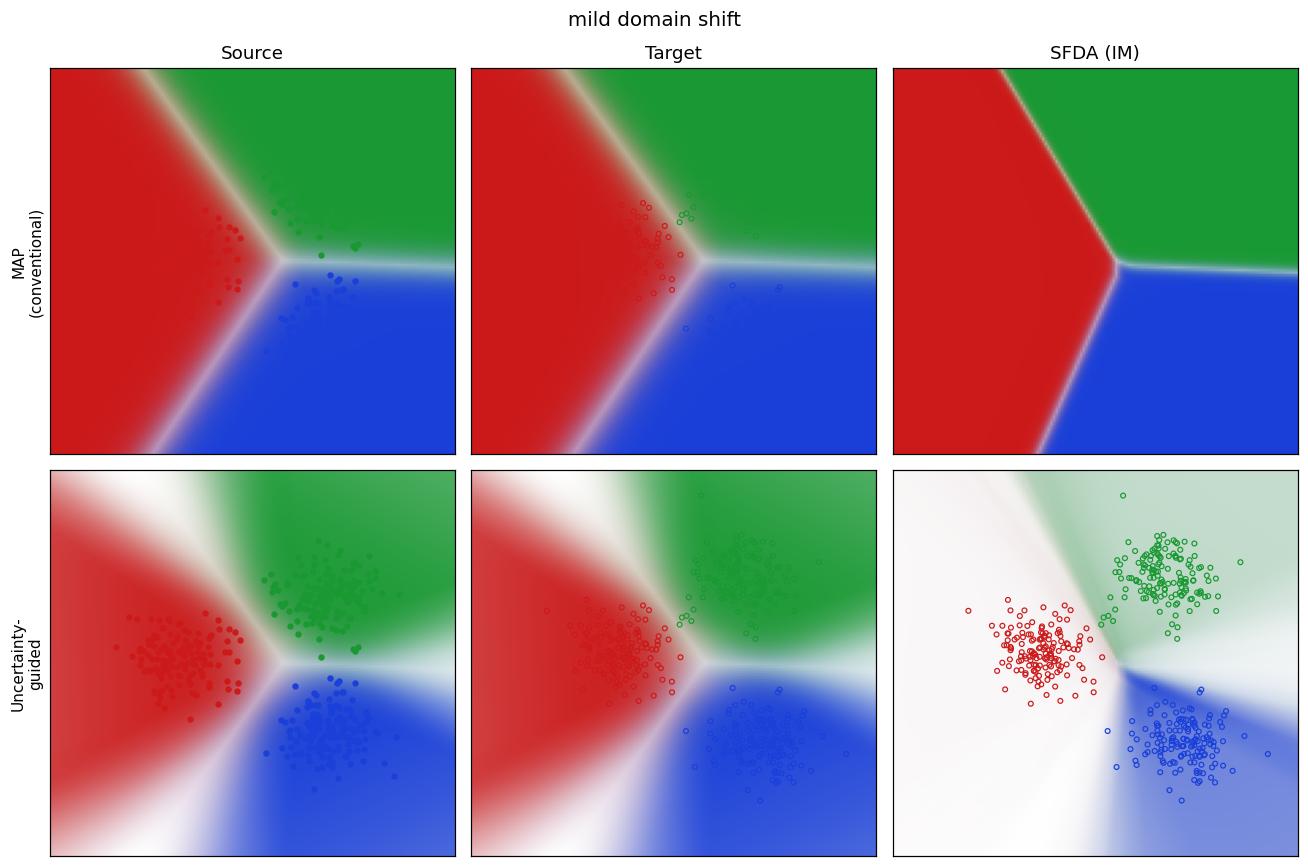

[mild] accuracy before adapt:              1.000  (blue only: 1.000)
[mild] accuracy after conventional IM:      1.000  (blue only: 1.000)
[mild] accuracy after uncertainty-guided IM: 1.000  (blue only: 1.000)



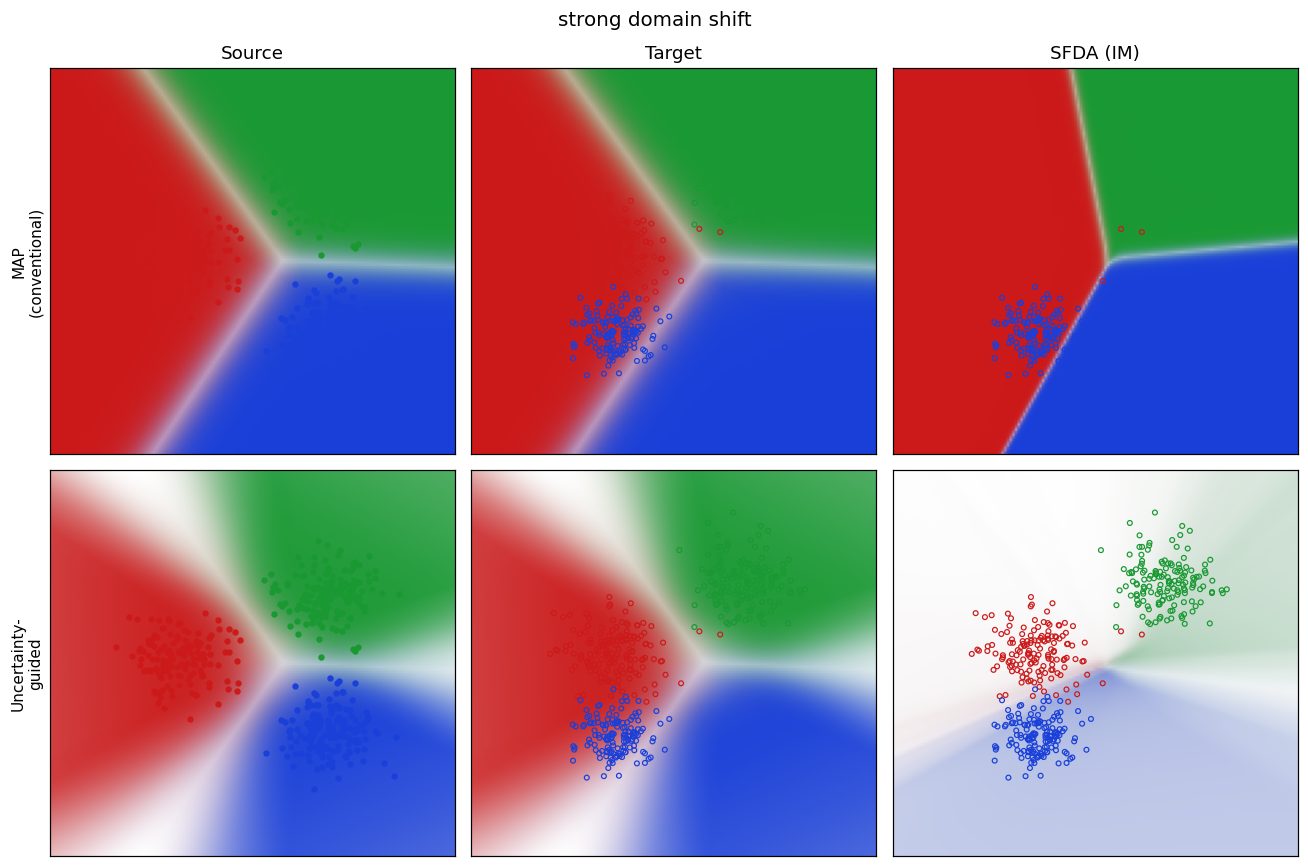

[strong] accuracy before adapt:              0.682  (blue only: 0.060)
[strong] accuracy after conventional IM:      0.684  (blue only: 0.073)
[strong] accuracy after uncertainty-guided IM: 0.971  (blue only: 0.987)



In [4]:
GAMMA = 0.2        # see note above (project default for the real ablation is 0.5)
TEMPERATURE = 0.4  # TODO.md fixed hyperparameter tau
ADAPT_STEPS = 300
ADAPT_LR = 1e-2
M_MC = 100


def map_surface(m):
    with torch.no_grad():
        probs = torch.softmax(m(grid_t), dim=-1).numpy()
    return toy.blended_surface(probs.reshape(*XX.shape, N))


def ug_surface(m, lap):
    out = lap.predictive(m, grid_t, M=200, generator=torch.Generator().manual_seed(SEED))
    probs = out["mean_probs"].numpy().reshape(*XX.shape, N)
    epi = out["epistemic"].numpy().reshape(*XX.shape)
    epi_norm = np.clip(epi / (epi.max() + 1e-8), 0, 1)
    return toy.blended_surface(probs, fade=epi_norm)


def run_regime(shift, target_seed):
    # adapt both variants on one target regime; return per-class accuracies
    Xt, yt = targets[shift]
    Xt_t = torch.as_tensor(Xt)

    model_map = copy.deepcopy(model)
    model_ug = copy.deepcopy(model)
    adapt_target(model_map, laplace, Xt_t, weight_mode="none", gamma=GAMMA,
                 temperature=TEMPERATURE, lr=ADAPT_LR, steps=ADAPT_STEPS, M=M_MC, seed=SEED)
    adapt_target(model_ug, laplace, Xt_t, weight_mode="uncertainty", gamma=GAMMA,
                 temperature=TEMPERATURE, lr=ADAPT_LR, steps=ADAPT_STEPS, M=M_MC, seed=SEED)

    with torch.no_grad():
        preds = {name: mdl(Xt_t).argmax(dim=1).numpy()
                 for name, mdl in [("before", model), ("map", model_map), ("ug", model_ug)]}
    blue = yt == 2
    acc = {k: (p == yt).mean() for k, p in preds.items()}
    blue_acc = {k: (p[blue] == 2).mean() for k, p in preds.items()}

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f"{shift} domain shift", fontsize=13)
    panels = [
        (axes[0, 0], map_surface(model),     Xs, ys, False),
        (axes[0, 1], map_surface(model),     Xt, yt, True),
        (axes[0, 2], map_surface(model_map), Xt, yt, True),
        (axes[1, 0], ug_surface(model, laplace),    Xs, ys, False),
        (axes[1, 1], ug_surface(model, laplace),    Xt, yt, True),
        (axes[1, 2], ug_surface(model_ug, laplace), Xt, yt, True),
    ]
    for ax, surf, X, y, hollow in panels:
        ax.imshow(surf, extent=extent, origin="lower", aspect="auto")
        scatter(ax, X, y, hollow=hollow)
    for ax, title in zip(axes[0], ["Source", "Target", "SFDA (IM)"]):
        ax.set_title(title)
    axes[0, 0].set_ylabel("MAP\n(conventional)", fontsize=10)
    axes[1, 0].set_ylabel("Uncertainty-\nguided", fontsize=10)
    fig.tight_layout()
    plt.show()

    print(f"[{shift}] accuracy before adapt:              {acc['before']:.3f}  (blue only: {blue_acc['before']:.3f})")
    print(f"[{shift}] accuracy after conventional IM:      {acc['map']:.3f}  (blue only: {blue_acc['map']:.3f})")
    print(f"[{shift}] accuracy after uncertainty-guided IM: {acc['ug']:.3f}  (blue only: {blue_acc['ug']:.3f})\n")
    return dict(acc=acc, blue_acc=blue_acc)


results = {shift: run_regime(shift, s) for shift, s in [("mild", 1), ("strong", 2)]}

Epistemic vs. aleatoric uncertainty maps of the **source** model (BALD decomposition, `TODO.md` Sec. 7): `total_entropy = H[E_theta p(y|x,theta)]`, `aleatoric = E_theta[H[p(y|x,theta)]]`, `epistemic = total - aleatoric`. The two probe points from the shared setup are marked; Box 2 turns this qualitative picture into a numeric check.

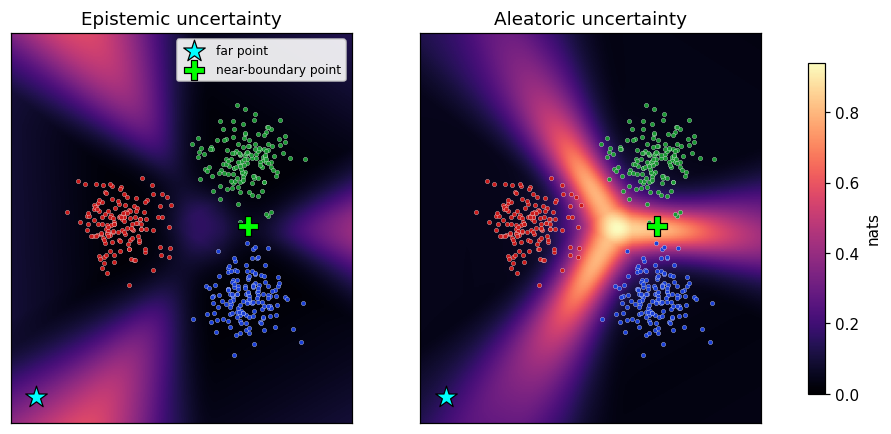

In [5]:
grid_out = laplace.predictive(model, grid_t, M=300,
                              generator=torch.Generator().manual_seed(SEED))
epi_grid = grid_out["epistemic"].numpy().reshape(XX.shape)
ale_grid = grid_out["aleatoric"].numpy().reshape(XX.shape)
vmax = max(epi_grid.max(), ale_grid.max())

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, (vals, title) in zip(axes, [(epi_grid, "Epistemic uncertainty"),
                                     (ale_grid, "Aleatoric uncertainty")]):
    im = ax.imshow(vals, extent=extent, origin="lower", aspect="auto",
                   cmap="magma", vmin=0, vmax=vmax)
    for k in range(N):
        m = ys == k
        ax.scatter(Xs[m, 0], Xs[m, 1], s=8, color=toy.CLASS_COLORS[k],
                   edgecolors="white", linewidths=0.2)
    ax.scatter(*FAR_POINT, marker="*", s=220, color="cyan",
               edgecolors="black", linewidths=0.8, label="far point")
    ax.scatter(*NEAR_BOUNDARY_POINT, marker="P", s=160, color="lime",
               edgecolors="black", linewidths=0.8, label="near-boundary point")
    ax.set_title(title)
    style_ax(ax)
axes[0].legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.colorbar(im, ax=axes, shrink=0.85, label="nats")
plt.show()

## Box 2 -- Semantic check

Quantitative version of what the maps above show qualitatively: a point far from every source cluster should be **epistemic-dominant** (the model doesn't know which weights to trust there), while a point deep inside the source support but sitting right at a class boundary should be **aleatoric-dominant** (the model knows its weights perfectly well -- the classes themselves just overlap there). A fixed RNG seed makes the assertions deterministic, so a failure means a real regression, not Monte-Carlo noise.

In [6]:
check_points = torch.as_tensor(probe_points)
out = laplace.predictive(model, check_points, M=2000,
                         generator=torch.Generator().manual_seed(SEED))

names = ["far point (outside source support)", "near-boundary point (inside source support)"]
for name, epi, ale, total in zip(names, out["epistemic"], out["aleatoric"], out["total_entropy"]):
    dominant = "epistemic" if epi > ale else "aleatoric"
    print(f"{name:48s} epistemic={epi.item():.4f}  aleatoric={ale.item():.4f}  "
          f"total={total.item():.4f}  -> {dominant}-dominant")

assert out["epistemic"][0] > out["aleatoric"][0], "far point should be epistemic-dominant"
assert out["aleatoric"][1] > out["epistemic"][1], "near-boundary in-support point should be aleatoric-dominant"
print("\nSemantic check passed: far-from-source -> epistemic-dominant; "
      "near-boundary in-distribution -> aleatoric-dominant.")

far point (outside source support)               epistemic=0.3404  aleatoric=0.1490  total=0.4893  -> epistemic-dominant
near-boundary point (inside source support)      epistemic=0.0642  aleatoric=0.7904  total=0.8547  -> aleatoric-dominant

Semantic check passed: far-from-source -> epistemic-dominant; near-boundary in-distribution -> aleatoric-dominant.


## Box 3 -- Shift-magnitude sweep (optional)

The blue cluster is dragged radially outward from the 3-class centroid, through its own source position and beyond, in ten steps of known Euclidean magnitude (`toy.make_classification_sweep`). Moving *outward* rather than towards another class keeps the sweep monotonic -- the cluster only ever gets farther from every source cluster, so mean epistemic uncertainty on the (ground-truth-known) shifted class should track shift magnitude with a strong, significant Spearman correlation.

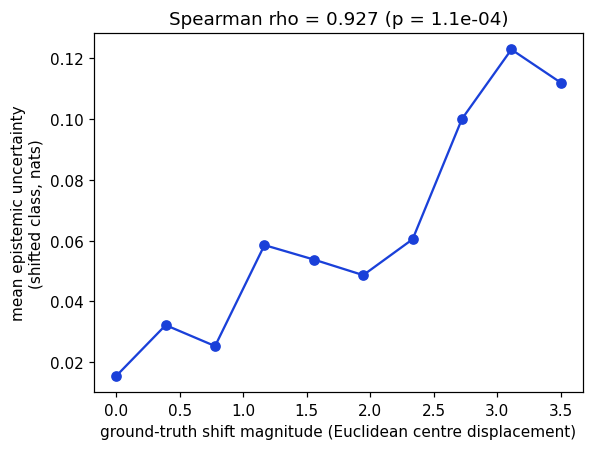

Spearman correlation between shift magnitude and mean epistemic uncertainty: rho=0.927, p=1.12e-04


In [7]:
levels = toy.make_classification_sweep(n_levels=10, seed=42)

shift_magnitudes, mean_epistemic = [], []
for i, level in enumerate(levels):
    Xt = torch.as_tensor(level["X"])
    blue_mask = level["y"] == 2
    out = laplace.predictive(model, Xt, M=300,
                             generator=torch.Generator().manual_seed(SEED + i))
    shift_magnitudes.append(level["shift_magnitude"])
    mean_epistemic.append(out["epistemic"][blue_mask].mean().item())

rho, p_value = spearmanr(shift_magnitudes, mean_epistemic)

fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.plot(shift_magnitudes, mean_epistemic, "o-", color=toy.CLASS_COLORS[2])
ax.set_xlabel("ground-truth shift magnitude (Euclidean centre displacement)")
ax.set_ylabel("mean epistemic uncertainty\n(shifted class, nats)")
ax.set_title(f"Spearman rho = {rho:.3f} (p = {p_value:.1e})")
fig.tight_layout()
plt.show()

print(f"Spearman correlation between shift magnitude and mean epistemic uncertainty: "
      f"rho={rho:.3f}, p={p_value:.2e}")
assert rho > 0.7 and p_value < 0.05, "expected a strong, significant positive correlation" 